# Compare performance of LFP-input to all vs just inh or exc

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *


2026-02-06 16:52:11.235486: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-06 16:52:11.243738: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-06 16:52:11.252537: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-06 16:52:11.255216: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-06 16:52:11.262526: I tensorflow/core/platform/cpu_feature_guar

### delay 400

In [2]:
# find folder names within model directory
all_lfp_models_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/'
lfp_model_dirs = ld.get_immediate_subdirs(all_lfp_models_dir)
theta4_dirs = [m for m in lfp_model_dirs if '4.0' in m] # 4Hz models only

print(theta4_dirs)
print(len(theta4_dirs))

['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121830', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_120946', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122821', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121810', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121802', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121301', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122352', 'Task_x

In [3]:
# remove the 4Hz models that did not perform well on the delay=50 task

importlib.reload(ld)

spiking_perf = []
for model_name in theta4_dirs:
    mat_data = ld.get_model(model_name, all_models_dir=all_lfp_models_dir)
    perf = np.max(mat_data['all_perfs'])
    spiking_perf.append(perf)
    
# remove low-perf models from theta4_dirs
high_perf_theta4_dirs = []
for i, perf in enumerate(spiking_perf):
    if perf >= 0.95:
        high_perf_theta4_dirs.append(theta4_dirs[i])
        
theta4_dirs = high_perf_theta4_dirs
print(f'New number of 4Hz models: {len(theta4_dirs)}')

New number of 4Hz models: 24


In [4]:
# get all of the 4Hz models and their performances

condns = ['delay400.', 'delay400inhonly', 'delay400exconly']

importlib.reload(ld)
theta4_models, theta4_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase='delay400.', condn_num='',
                                              model_list = theta4_dirs,
                                              all_models_dir = all_lfp_models_dir)

_, theta4_exconly_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase='delay400exconly', condn_num='',
                                              model_list = theta4_dirs,
                                              all_models_dir = all_lfp_models_dir)

_, theta4_inhonly_perfs = ld.get_models_by_perf(low_cutoff=-np.inf, high_cutoff=np.inf, 
                                              condn_phrase='delay400inhonly', condn_num='',
                                              model_list = theta4_dirs,
                                              all_models_dir = all_lfp_models_dir)

Found 24 models with performance between -inf and inf
Found 24 models with performance between -inf and inf
Found 24 models with performance between -inf and inf


[0, 22, 7, 16, 11, 9, 2, 15, 14, 8, 13, 3, 18, 21, 6, 19, 23, 4, 20, 17]
Wilcoxon signed-rank test (intact vs LFP to inh only): stat=97.500, p=0.779
Wilcoxon signed-rank test (intact vs LFP to exc only): stat=9.000, p=0.000


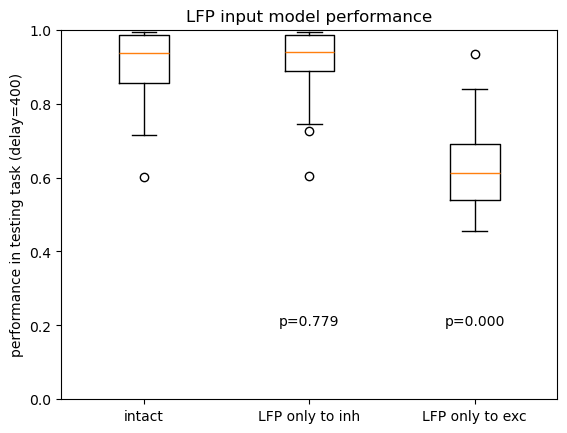

In [5]:
# make boxplot

i_model = [ 0, 22,  7, 16, 11,  9,  2, 15, 14,  8, 13,  3, 18, 21,  6, 19, 23,  4, 20, 17]
print(i_model)

avg_perf_lfp4 = [theta4_perfs[i_model], theta4_inhonly_perfs[i_model], theta4_exconly_perfs[i_model]]

plt.figure()
plt.boxplot([avg_perf_lfp4[0], avg_perf_lfp4[1], avg_perf_lfp4[2]], positions=[1, 2, 3])
plt.xticks([1, 2, 3], ['intact', 'LFP only to inh', 'LFP only to exc'])
plt.ylabel('performance in testing task (delay=400)')
plt.title('LFP input model performance')

from scipy.stats import wilcoxon
stat, p = wilcoxon(avg_perf_lfp4[0], avg_perf_lfp4[1])
print('Wilcoxon signed-rank test (intact vs LFP to inh only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(2, 0.2, 'p=%.3f' % p, ha='center')
stat, p = wilcoxon(avg_perf_lfp4[0], avg_perf_lfp4[2])
print('Wilcoxon signed-rank test (intact vs LFP to exc only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(3, 0.2, 'p=%.3f' % p, ha='center')
plt.ylim([0, 1])

# # save as eps
# plt.savefig('spiking_model_lesioninput_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

In [6]:
print(f'4Hz models— mean perf: {np.mean(theta4_perfs[i_model])}, std perf: {np.std(theta4_perfs[i_model])}')
print(f'4Hz inh-only models— mean perf: {np.mean(theta4_inhonly_perfs[i_model])}, std perf: {np.std(theta4_inhonly_perfs[i_model])}')
print(f'4Hz exc-only models— mean perf: {np.mean(theta4_exconly_perfs[i_model])}, std perf: {np.std(theta4_exconly_perfs[i_model])}')



4Hz models— mean perf: 0.89915, std perf: 0.10731089180507261
4Hz inh-only models— mean perf: 0.9047499999999999, std perf: 0.10524346773078128
4Hz exc-only models— mean perf: 0.631, std perf: 0.12397177098033245
